# What Drives Credit Card Transaction Fraud?

Interpretation-focused classification analysis on transaction-level data.

The goal here isn't just to flag fraud as accurately as possible — it's to understand
*which factors actually explain it*, in terms a fraud operations team could act on.
That framing affects a lot of the choices below, including which model I end up
recommending at the end.

## 1. The data

I couldn't find a public transaction-level fraud dataset with real, named features —
the well-known Kaggle credit card fraud dataset anonymizes everything into PCA
components (`V1`...`V28`), which makes it useless for an interpretation exercise since
you can't explain what `V14` means to a stakeholder. So I built a simulated dataset
instead: ~100k transactions from ~8,000 customers over a 6-month window, with fraud
probability driven by a mix of realistic signals (spend anomalies, travel/distance
patterns, odd hours, risky merchant categories, transaction velocity) plus noise, so
the signal is there but not perfectly clean. The generator is in `data/generate_data.py`
if you want to see exactly how it's built.

Columns as they come in:

| column | description |
|---|---|
| transaction_id, customer_id | identifiers |
| timestamp | when the transaction happened |
| amount | transaction amount (INR) |
| merchant_category | grocery, restaurant, electronics, jewelry, etc. |
| channel | card_present, online, atm_withdrawal |
| home_lat / home_lon | customer's registered address coordinates |
| txn_lat / txn_lon | coordinates of the transaction |
| customer_age, account_tenure_months | customer profile |
| avg_amount_30d | customer's typical spend baseline |
| is_foreign_txn | flag |
| is_fraud | target |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                              recall_score, f1_score, confusion_matrix, roc_curve,
                              precision_recall_curve, classification_report)
import xgboost as xgb
import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/transactions.csv", parse_dates=["timestamp"])
print(df.shape)
df.head()

(100000, 15)


,transaction_id,customer_id,timestamp,amount,merchant_category,channel,home_lat,home_lon,txn_lat,txn_lon,customer_age,account_tenure_months,avg_amount_30d,is_foreign_txn,is_fraud
0,1,5050,2025-09-01 00:10:36,585.26,gift_cards,card_present,15.28987,89.07071,15.16860,89.68461,50,21,560.86,0,0
1,2,3956,2025-09-01 01:03:46,2181.41,utilities,atm_withdrawal,31.35080,82.28846,31.87346,82.16981,18,13,2370.99,0,0
2,3,6382,2025-09-01 01:34:56,290.62,restaurant,online,25.29498,71.65120,24.72376,71.77077,27,34,1163.68,0,0
3,4,5552,2025-09-01 01:58:37,1842.20,grocery,card_present,21.23596,85.73346,21.39004,85.38259,36,1,2377.00,0,0
4,5,5577,2025-09-01 02:28:54,891.62,entertainment,online,18.44804,89.13029,15.47476,81.59639,42,70,1485.70,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   transaction_id         100000 non-null  int64         
 1   customer_id            100000 non-null  int64         
 2   timestamp              100000 non-null  datetime64[us]
 3   amount                 100000 non-null  float64       
 4   merchant_category      100000 non-null  str           
 5   channel                100000 non-null  str           
 6   home_lat               100000 non-null  float64       
 7   home_lon               100000 non-null  float64       
 8   txn_lat                100000 non-null  float64       
 9   txn_lon                100000 non-null  float64       
 10  customer_age           100000 non-null  int64         
 11  account_tenure_months  100000 non-null  int64         
 12  avg_amount_30d         100000 non-null  float64       
 

In [4]:
df.describe()

,transaction_id,customer_id,timestamp,amount,home_lat,home_lon,txn_lat,txn_lon,customer_age,account_tenure_months,avg_amount_30d,is_foreign_txn,is_fraud
count,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,4008.338630,2025-11-30 02:14:41.342080,954.884986,21.079085,82.961590,21.085112,82.956937,37.951090,27.750750,941.242714,0.019680,0.015940
min,1.000000,1.000000,2025-09-01 00:10:36,50.000000,9.000460,70.001230,6.000000,66.000000,18.000000,1.000000,200.000000,0.000000,0.000000
25%,25000.750000,2027.000000,2025-10-15 17:25:52.250000,274.922500,15.075392,76.387960,15.078862,76.375555,30.000000,8.000000,557.420000,0.000000,0.000000
50%,50000.500000,4007.000000,2025-11-29 21:13:10.500000,511.245000,21.211760,82.887380,21.233105,82.899455,38.000000,19.000000,804.470000,0.000000,0.000000
75%,75000.250000,6001.000000,2026-01-14 08:21:54.500000,1021.795000,27.121800,89.399070,27.143220,89.392843,46.000000,39.000000,1171.020000,0.000000,0.000000
max,100000.000000,8000.000000,2026-02-27 23:59:23,46058.980000,32.999580,95.998880,37.000000,99.000000,79.000000,180.000000,8776.270000,1.000000,1.000000
std,28867.657797,2301.212993,NaN,1477.766790,6.923701,7.505587,6.997849,7.580020,11.382433,28.125228,568.974272,0.138899,0.125244


Quick check for the obvious stuff — nulls and duplicate rows.

In [5]:
print("nulls:", df.isnull().sum().sum())
print("duplicate rows:", df.duplicated().sum())
print("duplicate transaction_ids:", df["transaction_id"].duplicated().sum())

nulls: 0
duplicate rows: 0
duplicate transaction_ids: 0


Clean. No missing values, no duplicates — makes sense since this came from a
generator, but I'd never skip this check on real data.

## 2. Exploratory data analysis

### Class imbalance

First thing that matters for everything downstream: how rare is fraud here?

fraud rate: 1.594%
is_fraud
0    98406
1     1594
Name: count, dtype: int64


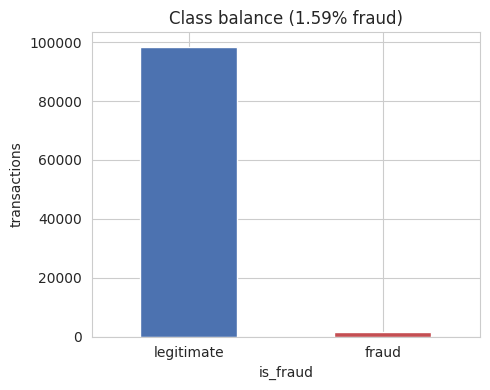

In [6]:
fraud_rate = df["is_fraud"].mean()
print(f"fraud rate: {fraud_rate:.3%}")
print(df["is_fraud"].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
df["is_fraud"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["legitimate", "fraud"], rotation=0)
ax.set_ylabel("transactions")
ax.set_title(f"Class balance ({fraud_rate:.2%} fraud)")
plt.tight_layout()
plt.show()

Under 2% fraud. This matters a lot for how I evaluate models later — plain
accuracy would be meaningless here (predicting "not fraud" for everything gets 98.4%
accuracy and catches zero fraud), so precision, recall, F1 and PR-AUC matter more than
accuracy or even ROC-AUC alone.

### Fraud rate by merchant category

In [7]:
cat_fraud = df.groupby("merchant_category")["is_fraud"].agg(["mean", "count"]).sort_values("mean", ascending=False)
cat_fraud.columns = ["fraud_rate", "n_transactions"]
cat_fraud

,fraud_rate,n_transactions
merchant_category,,
jewelry,0.098053,1438
travel,0.076482,4014
electronics,0.056609,3957
online_retail,0.024185,14885
gift_cards,0.020676,2515
healthcare,0.017279,5035
utilities,0.007769,5020
entertainment,0.006866,8010
grocery,0.006857,24938


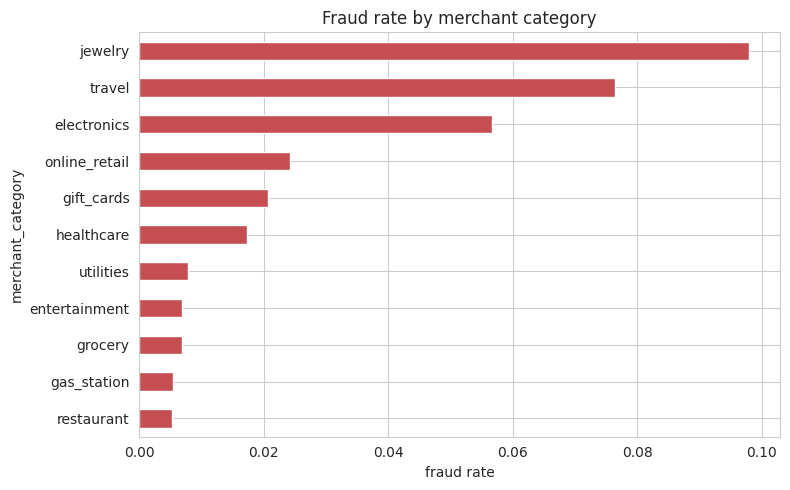

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
cat_fraud["fraud_rate"].plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("fraud rate")
ax.set_title("Fraud rate by merchant category")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Jewelry and travel stand out — both around 5-10x the overall fraud rate, followed
by electronics. Grocery and restaurant transactions are the safest by a wide margin.
Not surprising in hindsight (higher resale value, easier to monetize stolen funds
quickly), but useful to confirm it shows up in the data.

### Fraud rate by channel

In [9]:
channel_fraud = df.groupby("channel")["is_fraud"].mean().sort_values(ascending=False)
channel_fraud

channel
online            0.020171
atm_withdrawal    0.016171
card_present      0.014167
Name: is_fraud, dtype: float64

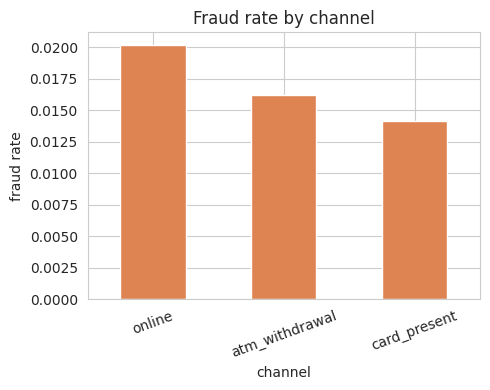

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
channel_fraud.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_ylabel("fraud rate")
ax.set_title("Fraud rate by channel")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Online transactions run about 40% higher fraud rate than card-present, which
tracks with the usual card-not-present fraud story. The gap isn't as dramatic as
merchant category though.

### Time of day

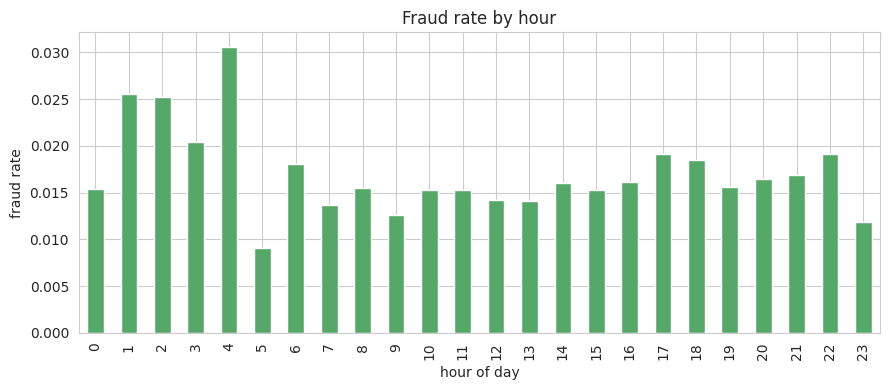

In [11]:
hour_fraud = df.groupby(df["timestamp"].dt.hour)["is_fraud"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
hour_fraud.plot(kind="bar", ax=ax, color="#55A868")
ax.set_xlabel("hour of day")
ax.set_ylabel("fraud rate")
ax.set_title("Fraud rate by hour")
plt.tight_layout()
plt.show()

There's a visible bump in the early hours (1-4am) but it's noisy — small hour-by-hour
sample sizes mean this isn't as clean a signal as category or channel. I'll treat hour
as a secondary feature rather than a headline driver.

### Transaction amount

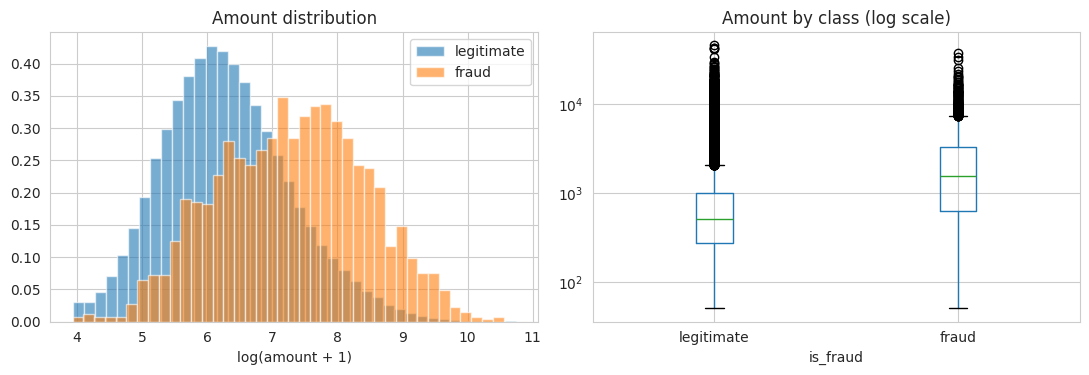

is_fraud
0     505.345
1    1548.885
Name: amount, dtype: float64

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, group in df.groupby("is_fraud"):
    axes[0].hist(np.log1p(group["amount"]), bins=40, alpha=0.6,
                 label="fraud" if label == 1 else "legitimate", density=True)
axes[0].set_xlabel("log(amount + 1)")
axes[0].set_title("Amount distribution")
axes[0].legend()

df.boxplot(column="amount", by="is_fraud", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_xticklabels(["legitimate", "fraud"])
axes[1].set_title("Amount by class (log scale)")
plt.suptitle("")
plt.tight_layout()
plt.show()

df.groupby("is_fraud")["amount"].median()

Fraudulent transactions run noticeably higher — median amount is about 3x the
legitimate median. But there's real overlap in the distributions too, so amount alone
isn't a clean separator; it's more useful relative to what a given customer usually
spends, which is why I engineer a ratio feature for it below rather than using raw
amount on its own.

## 3. Feature engineering

None of the interesting signal is sitting in the raw columns as-is — it has to be
derived. Four engineered features, in order of how much I expect them to matter:

- **`amount_to_avg_ratio`** — this transaction's amount relative to the customer's own
  30-day average. A ₹5,000 transaction means something different for someone who
  usually spends ₹500 vs. someone who usually spends ₹8,000.
- **`distance_from_home_km`** and **`distance_from_last_txn_km`** — haversine distance
  from the customer's home address, and from their previous transaction. The second one
  in particular should catch "impossible travel" patterns.
- **`time_since_last_txn_hrs`** and **`transactions_last_24h`** — velocity features.
  Fraud often comes in short bursts once a card is compromised.
- **`hour_of_day`** and **`is_weekend`** — pulled out of the timestamp.

Distance and velocity both require the data sorted by customer and time first.

In [13]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


df = df.sort_values(["customer_id", "timestamp"]).reset_index(drop=True)
grp = df.groupby("customer_id")

df["time_since_last_txn_hrs"] = (df["timestamp"] - grp["timestamp"].shift(1)).dt.total_seconds() / 3600
df["time_since_last_txn_hrs"] = df["time_since_last_txn_hrs"].fillna(9999)  # first txn for a customer

df["distance_from_last_txn_km"] = haversine_km(
    grp["txn_lat"].shift(1), grp["txn_lon"].shift(1), df["txn_lat"], df["txn_lon"]
).fillna(0)

df["distance_from_home_km"] = haversine_km(df["home_lat"], df["home_lon"], df["txn_lat"], df["txn_lon"])

tmp = df.set_index("timestamp")
df["transactions_last_24h"] = (
    tmp.groupby("customer_id")["transaction_id"]
    .rolling("24h", closed="left").count()
    .fillna(0).reset_index(drop=True)
)

df["hour_of_day"] = df["timestamp"].dt.hour
df["is_weekend"] = df["timestamp"].dt.dayofweek.isin([5, 6]).astype(int)
df["amount_to_avg_ratio"] = df["amount"] / df["avg_amount_30d"]

df = df.sort_values("transaction_id").reset_index(drop=True)
df[["distance_from_home_km", "distance_from_last_txn_km", "time_since_last_txn_hrs",
    "transactions_last_24h", "amount_to_avg_ratio"]].describe()

,distance_from_home_km,distance_from_last_txn_km,time_since_last_txn_hrs,transactions_last_24h,amount_to_avg_ratio
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,78.770224,116.875327,1041.260630,0.104140,1.011862
std,147.372967,194.249224,2634.601906,0.327683,1.226913
min,0.088955,0.000000,0.003333,0.000000,0.049989
25%,29.301220,36.355770,70.875764,0.000000,0.381559
50%,46.036042,63.752342,186.994444,0.000000,0.611299
75%,66.749587,98.337962,451.209861,0.000000,1.091294
max,1994.176297,2250.953264,9999.000000,4.000000,22.574963


`time_since_last_txn_hrs` has a fill value of 9999 for each customer's first
transaction on record (no prior transaction to compare to) — worth remembering when
reading the summary stats, since it drags the max way up. Everything else looks
sensible.

### Encoding categoricals

In [14]:
df_model = pd.get_dummies(df, columns=["merchant_category", "channel"], drop_first=True)

feature_cols = [
    "amount", "distance_from_home_km", "distance_from_last_txn_km", "time_since_last_txn_hrs",
    "customer_age", "account_tenure_months", "avg_amount_30d", "amount_to_avg_ratio",
    "transactions_last_24h", "hour_of_day", "is_weekend", "is_foreign_txn",
] + [c for c in df_model.columns if c.startswith("merchant_category_") or c.startswith("channel_")]

print(len(feature_cols), "features")
feature_cols

24 features


['amount',
 'distance_from_home_km',
 'distance_from_last_txn_km',
 'time_since_last_txn_hrs',
 'customer_age',
 'account_tenure_months',
 'avg_amount_30d',
 'amount_to_avg_ratio',
 'transactions_last_24h',
 'hour_of_day',
 'is_weekend',
 'is_foreign_txn',
 'merchant_category_entertainment',
 'merchant_category_gas_station',
 'merchant_category_gift_cards',
 'merchant_category_grocery',
 'merchant_category_healthcare',
 'merchant_category_jewelry',
 'merchant_category_online_retail',
 'merchant_category_restaurant',
 'merchant_category_travel',
 'merchant_category_utilities',
 'channel_card_present',
 'channel_online']

One-hot encoding with `drop_first=True` drops `electronics` as the baseline
category (alphabetically first), so every merchant category coefficient later should
be read as "risk relative to electronics," which is itself one of the higher-risk
categories — worth keeping in mind when I get to the logistic regression coefficients.

### Train/test split

Stratifying on the target since fraud is rare enough that a random split could
otherwise leave the test set with an unrepresentative fraud count.

In [15]:
X = df_model[feature_cols]
y = df_model["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("train:", X_train.shape, "fraud rate:", y_train.mean())
print("test: ", X_test.shape, "fraud rate:", y_test.mean())

train: (75000, 24) fraud rate: 0.015946666666666668
test:  (25000, 24) fraud rate: 0.01592


## 4. Models

Four classifiers, deliberately spanning the explainability-predictability spectrum:
logistic regression and a shallow decision tree are transparent by construction;
random forest and XGBoost trade some of that transparency for (potentially) better
predictive power, so I lean on feature importances and SHAP to interpret them instead
of reading individual coefficients.

All four use `class_weight='balanced'` (or the XGBoost equivalent, `scale_pos_weight`)
since a 1.6% fraud rate means an unweighted model would just learn to mostly predict
"not fraud."

I'll track the same five metrics for every model so they're directly comparable at
the end: ROC-AUC, PR-AUC, precision, recall, F1 (all at the default 0.5 threshold).

In [16]:
results = {}


def evaluate(name, y_proba, y_pred):
    results[name] = {
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }
    print(f"--- {name} ---")
    print(pd.Series(results[name]).round(4))
    print()
    print(confusion_matrix(y_test, y_pred))
    return results[name]

### Model 1 — Logistic Regression (baseline, fully interpretable)

Scaling first since logistic regression coefficients aren't comparable across features
otherwise — a coefficient on `amount` (scale of thousands) and one on `is_weekend`
(0 or 1) mean very different things unless both are standardized first.

In [17]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)

proba = logreg.predict_proba(X_test_s)[:, 1]
pred = logreg.predict(X_test_s)
_ = evaluate("logreg", proba, pred)

--- logreg ---
roc_auc      0.9549
pr_auc       0.4192
precision    0.1255
recall       0.8794
f1           0.2196
dtype: float64

[[22163  2439]
 [   48   350]]


High recall (catches most fraud) but precision is rough — most of what it flags
turns out to be legitimate. That's the class-weighting doing its job (it's tuned to
not miss fraud) but it comes at a real cost in false alarms. Let's look at what's
actually driving the predictions before judging it on numbers alone.

In [18]:
coefs = pd.Series(logreg.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
odds_ratios = np.exp(coefs)

coef_table = pd.DataFrame({"coefficient": coefs, "odds_ratio": odds_ratios}).head(10)
coef_table

,coefficient,odds_ratio
time_since_last_txn_hrs,-1.297639,0.273176
transactions_last_24h,0.810819,2.249749
amount_to_avg_ratio,0.711858,2.037775
distance_from_home_km,0.611924,1.843976
distance_from_last_txn_km,0.604232,1.829846
merchant_category_gas_station,-0.561670,0.570256
merchant_category_grocery,-0.556862,0.573004
merchant_category_restaurant,-0.554889,0.574136
merchant_category_entertainment,-0.461225,0.630511
merchant_category_utilities,-0.344411,0.708638


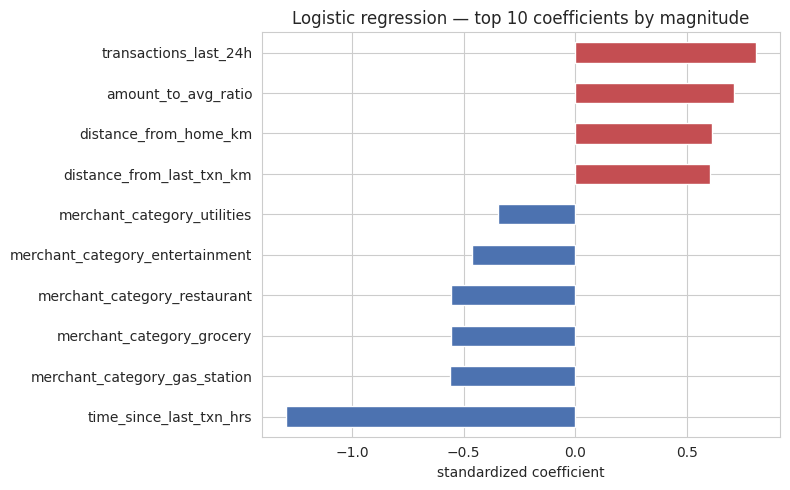

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
coefs.head(10).sort_values().plot(kind="barh", ax=ax,
                                   color=coefs.head(10).sort_values().apply(lambda v: "#C44E52" if v > 0 else "#4C72B0"))
ax.set_xlabel("standardized coefficient")
ax.set_title("Logistic regression — top 10 coefficients by magnitude")
plt.tight_layout()
plt.show()

Since every numeric feature was standardized first, each coefficient is "per one
standard deviation." A few read cleanly:

- `transactions_last_24h`: odds ratio ≈ 2.25 — a one-SD jump in recent transaction
  velocity roughly doubles the odds of fraud.
- `amount_to_avg_ratio`: odds ratio ≈ 2.0 — spending well above your own normal baseline
  matters more than the raw amount does.
- `distance_from_home_km` and `distance_from_last_txn_km`: both around 1.8x — being far
  from home, or a big jump from the previous transaction location, each roughly
  double the odds on their own.
- `time_since_last_txn_hrs` is negative (odds ratio ≈ 0.27) — makes sense given the
  velocity feature above: a longer gap since the last transaction is protective,
  rapid repeat activity is not.

The negative merchant-category coefficients (grocery, restaurant, gas station,
entertainment, utilities) are all being measured relative to `electronics` — since
that's the dropped baseline and one of the riskier categories, this reads as "these
categories are safer than electronics," not "these categories are safe in absolute
terms."

### Model 2 — Decision Tree (shallow, for interpretability)

Capped at depth 5 deliberately — deep trees stop being readable as a set of rules,
which defeats the point of using one here.

In [20]:
tree = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
tree.fit(X_train, y_train)

proba = tree.predict_proba(X_test)[:, 1]
pred = tree.predict(X_test)
_ = evaluate("tree", proba, pred)

--- tree ---
roc_auc      0.9390
pr_auc       0.3724
precision    0.0992
recall       0.8643
f1           0.1780
dtype: float64

[[21479  3123]
 [   54   344]]


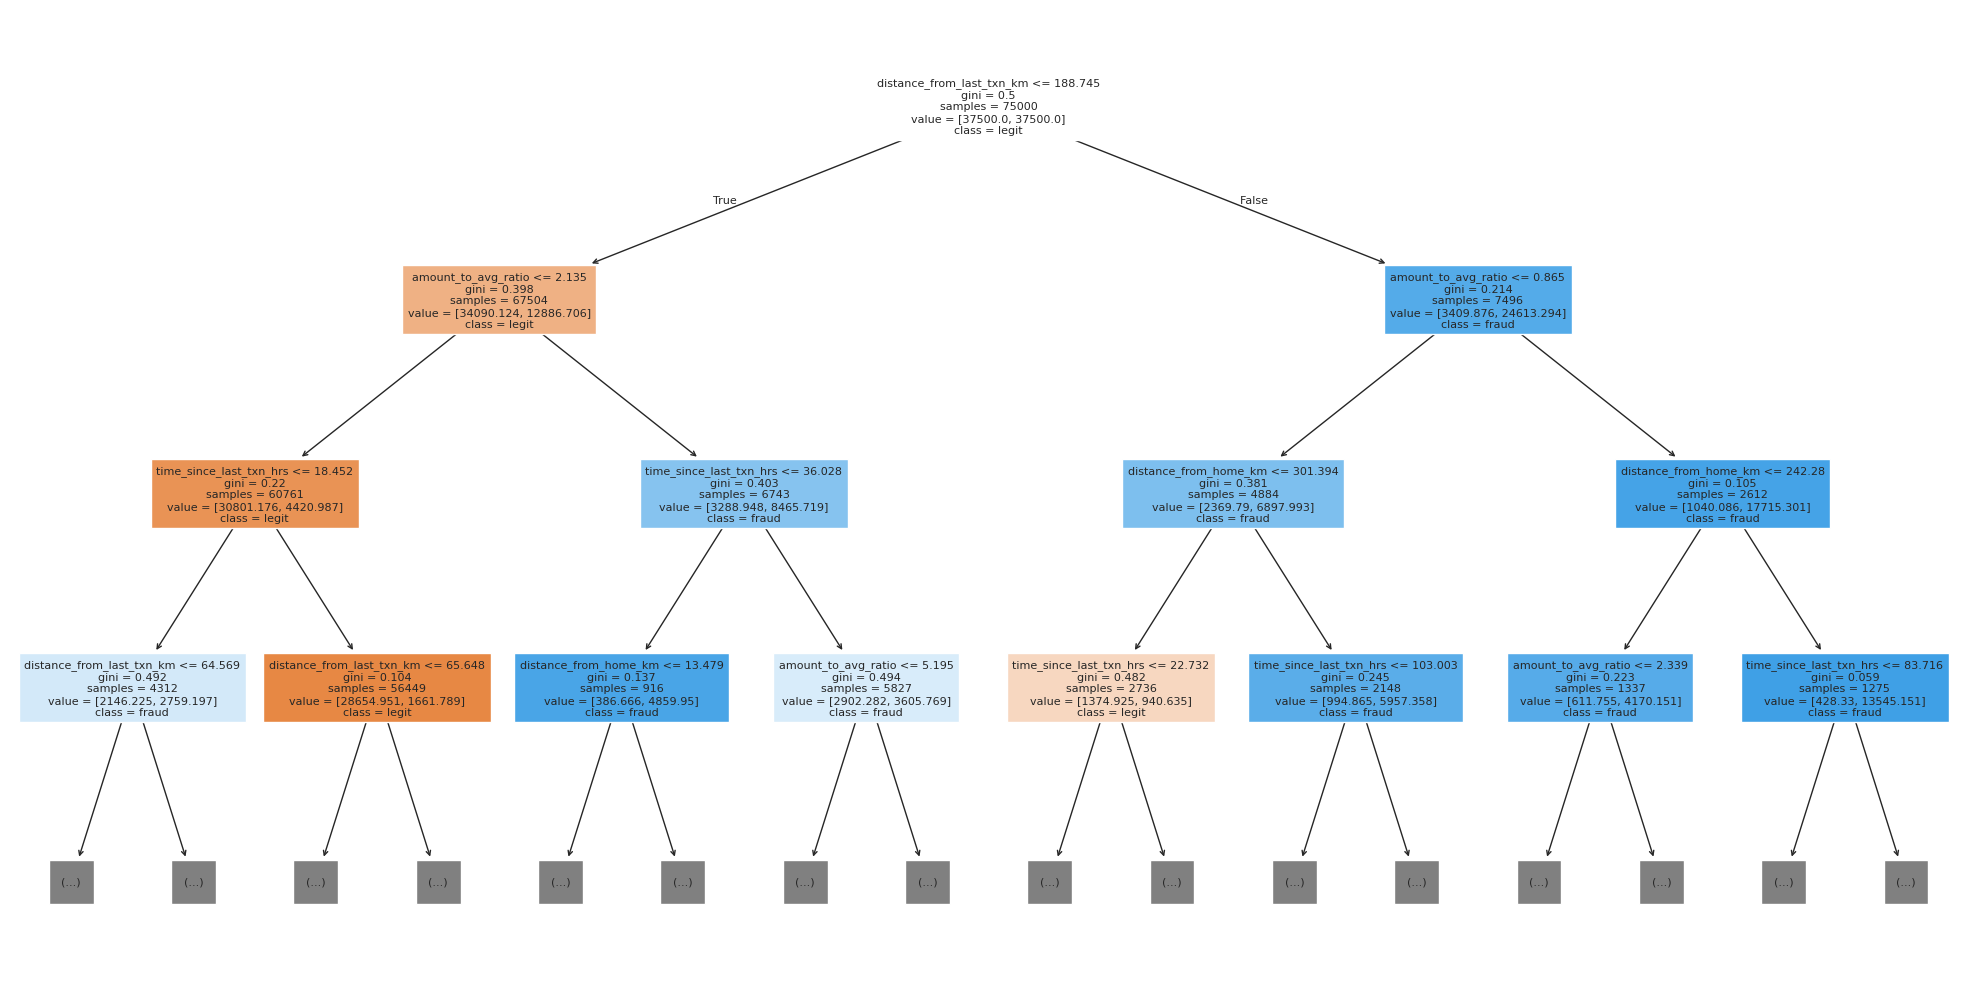

In [21]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(tree, feature_names=feature_cols, class_names=["legit", "fraud"],
          filled=True, max_depth=3, fontsize=8, ax=ax)
plt.tight_layout()
plt.show()

In [22]:
tree_imp = pd.Series(tree.feature_importances_, index=feature_cols).sort_values(ascending=False)
tree_imp[tree_imp > 0]

distance_from_last_txn_km    0.516444
amount_to_avg_ratio          0.288645
time_since_last_txn_hrs      0.151295
distance_from_home_km        0.039135
account_tenure_months        0.004481
dtype: float64

The tree leans almost entirely on four features — `distance_from_last_txn_km`,
`amount_to_avg_ratio`, `time_since_last_txn_hrs`, `distance_from_home_km` — which
lines up well with what logistic regression found, just expressed as split rules
instead of coefficients. It's the weakest performer of the four on every metric,
though, which is a real cost of keeping it shallow enough to read.

### Model 3 — Random Forest

In [23]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
pred = rf.predict(X_test)
_ = evaluate("rf", proba, pred)

--- rf ---
roc_auc      0.9548
pr_auc       0.4173
precision    0.2166
recall       0.7362
f1           0.3347
dtype: float64

[[23542  1060]
 [  105   293]]


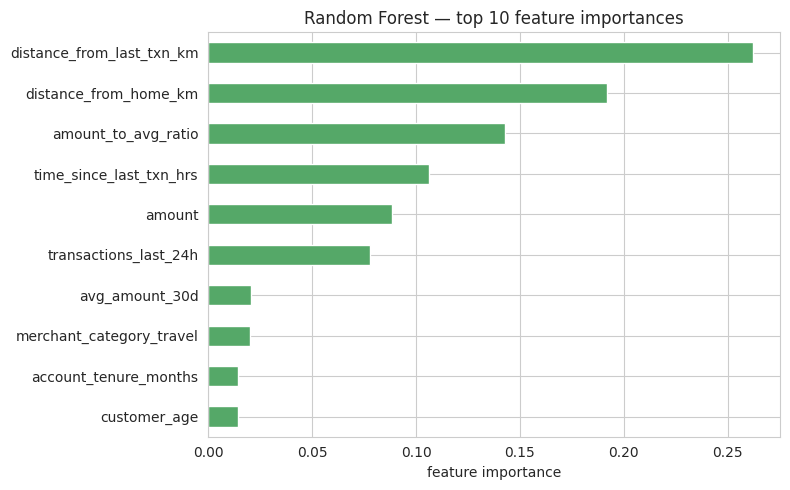

distance_from_last_txn_km    0.262081
distance_from_home_km        0.191787
amount_to_avg_ratio          0.142955
time_since_last_txn_hrs      0.106079
amount                       0.088317
transactions_last_24h        0.077825
avg_amount_30d               0.020640
merchant_category_travel     0.020138
account_tenure_months        0.014508
customer_age                 0.014286
dtype: float64

In [24]:
rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
rf_imp.head(10).sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("feature importance")
ax.set_title("Random Forest — top 10 feature importances")
plt.tight_layout()
plt.show()

rf_imp.head(10)

Precision jumps quite a bit versus logistic regression (roughly 22% vs. 13%)
without losing too much recall, which is the ensemble doing what it's supposed to —
and the top features are, again, the same five or six showing up. That consistency
across three very different model types is itself worth treating as a finding: it
suggests these aren't artifacts of any one algorithm's quirks.

### Model 4 — XGBoost

In [25]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

proba = xgb_model.predict_proba(X_test)[:, 1]
pred = xgb_model.predict(X_test)
_ = evaluate("xgb", proba, pred)

--- xgb ---
roc_auc      0.9415
pr_auc       0.4683
precision    0.2268
recall       0.7010
f1           0.3428
dtype: float64

[[23651   951]
 [  119   279]]


Best PR-AUC and F1 of the four, though the least directly readable — feature
importances still help, but for something this size SHAP values give a better sense
of not just *which* features matter but *how* each one pushes predictions up or down.

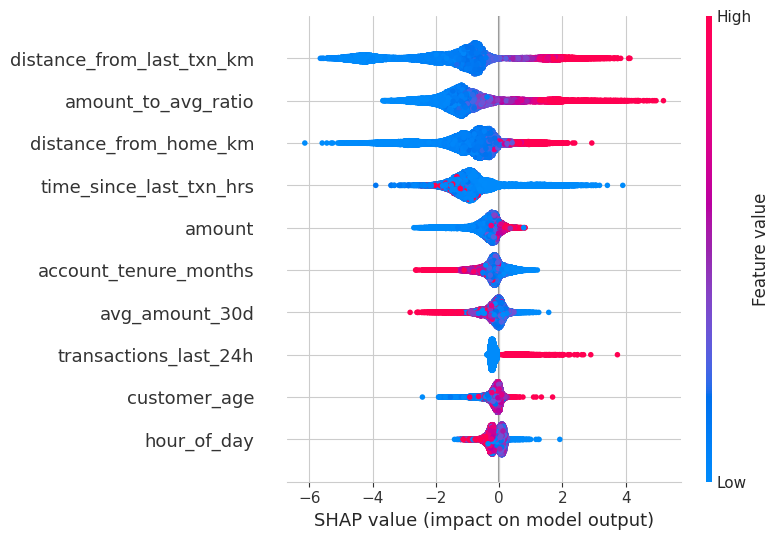

In [26]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False, max_display=10)
plt.tight_layout()
plt.show()

Same core set of drivers again, and the color gradient shows the *direction*
clearly: high values (red) of `distance_from_last_txn_km`, `amount_to_avg_ratio`, and
`transactions_last_24h` push predictions toward fraud, while high values of
`time_since_last_txn_hrs` push away from it. That's the fourth model in a row landing
on essentially the same story, using four different mechanisms to get there
(coefficients, split rules, impurity-based importance, and SHAP values).

## 5. Model comparison and recommendation

In [27]:
comparison = pd.DataFrame(results).T.round(4)
comparison = comparison[["roc_auc", "pr_auc", "precision", "recall", "f1"]]
comparison

,roc_auc,pr_auc,precision,recall,f1
logreg,0.9549,0.4192,0.1255,0.8794,0.2196
tree,0.9390,0.3724,0.0992,0.8643,0.1780
rf,0.9548,0.4173,0.2166,0.7362,0.3347
xgb,0.9415,0.4683,0.2268,0.7010,0.3428


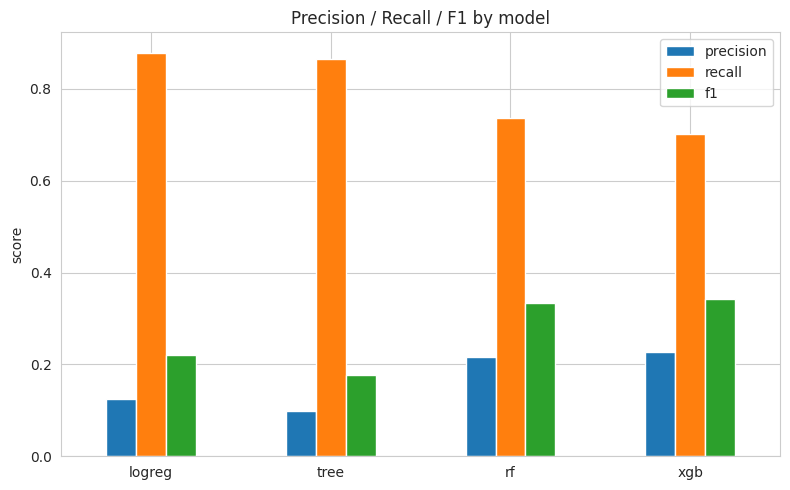

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison[["precision", "recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_ylabel("score")
ax.set_title("Precision / Recall / F1 by model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

All four models land in a fairly tight ROC-AUC band (0.94-0.96), so ranking
ability alone doesn't separate them much. The real differences show up in PR-AUC and
in the precision/recall trade-off at a standard threshold:

- **Logistic Regression** and the **Decision Tree** both lean heavily toward recall
  (88% and 86%) at the cost of precision (12-13% and 10%) — they catch almost all
  fraud but flag a large number of legitimate transactions along with it.
- **Random Forest** and **XGBoost** land in a more usable middle ground — noticeably
  better precision (22-23%) with still-solid recall (70-74%), and the two best F1
  and PR-AUC scores.

Given the objective here is *interpretation*, not pure prediction, I don't think the
answer is simply "pick the simplest model." A model that's fully transparent but
generates seven false alarms for every real fraud case caught isn't actually that
useful to a fraud operations team, however clean its coefficients are.

**My recommendation: Random Forest**, for a specific reason — its top features match
logistic regression's coefficients almost exactly, so I'm not trading away
interpretability nearly as much as it might first appear; I'm trading away the ability
to state an exact odds ratio for each feature. In exchange it gets meaningfully better
precision and F1 than the fully transparent models. I'd keep the logistic regression
model alongside it specifically as the "reference model" for stakeholders who want a
precise, quantified answer to "how much does X increase risk" — the two models agree
closely enough on direction and relative importance that using logistic regression's
odds ratios to describe Random Forest's behavior in plain language is a reasonable
thing to do, not a stretch.

XGBoost is a close second and technically the strongest on PR-AUC, but SHAP output
takes more explaining to a non-technical audience than "distance from your last
transaction" showing up as a tree split or a bar chart of feature importances — for
this specific audience and objective, I'd hold it in reserve rather than lead with it.

## 6. Key findings and insights

Pulling together what showed up consistently across all four models:

1. **Distance-based features are the strongest signal.** Both distance from home and
   distance from the customer's previous transaction matter, with the latter edging
   out as slightly stronger — consistent with an "impossible travel" pattern (a
   transaction location that couldn't realistically follow the previous one) being
   one of the clearest fraud tells in this data.

2. **Spending relative to the customer's own baseline matters more than raw amount.**
   `amount_to_avg_ratio` consistently outranks `amount` itself across every model.
   A ₹4,000 transaction is a very different signal for a customer who typically
   spends ₹300 versus one who typically spends ₹5,000 — treating amount in isolation
   would have missed this.

3. **Velocity is a real driver, but a two-sided one.** Multiple transactions in a
   short window raises risk, while a long gap since the last transaction lowers it —
   these aren't two separate weak signals, they're the same underlying pattern
   (rapid repeat activity after a card is compromised) showing up from both directions.

4. **Merchant category carries real signal but is secondary to behavioral features.**
   Jewelry, travel, and electronics run several times the baseline fraud rate, but
   none of the category dummies crack the top 5 in any model's importance ranking —
   category shifts the baseline risk, but the behavioral/distance features are what
   the models actually lean on to separate individual cases.

5. **Hour of day and weekend timing turned out to be weak.** These showed a visible
   bump in the EDA (late night transactions), but neither ranks meaningfully in any
   model's feature importance once the stronger features are in the mix — likely
   because the distance and velocity features already capture most of what "unusual
   timing" was a rough proxy for.

For a fraud operations team, the practical takeaway is that a rule built purely
around transaction amount or merchant category — the two most intuitive, commonly
used levers — would badly underperform one built around the customer's own behavioral
baseline and recent transaction geography.

## 7. Limitations and next steps

**This is simulated data, not real transaction records.** That's the biggest caveat by
far. I built the fraud signal myself based on patterns that show up in fraud detection
literature, so the model is, to some extent, learning to recover a signal I designed
in — real fraud is messier, evolves over time as fraudsters adapt, and includes
patterns I likely haven't thought to simulate (collusion between merchant and
cardholder, synthetic identity fraud building up account history before striking,
etc.). The realistic next step is validating this feature set and modeling approach
against real transaction data, which would need a data-sharing arrangement with a
bank or payment processor.

**Class imbalance handling was fairly basic.** I used class weighting throughout,
but didn't try SMOTE, undersampling, or anomaly-detection-style approaches
(isolation forests, autoencoders), any of which might change the precision/recall
trade-off meaningfully. Worth trying if this were going further.

**No temporal validation.** I used a random stratified split, but in a real deployment
a model trained on data through a given date needs to keep working on transactions
*after* that date, and fraud patterns shift over time. A time-based split (train on
the first N months, test on the last month) would be a more honest test of real-world
performance than what I've done here.

**Threshold was left at the sklearn default (0.5) throughout.** For an actual
deployment, the threshold should be tuned to whatever precision/recall trade-off
the business is willing to accept — the comparison above would look different at
a threshold chosen specifically to hit, say, a target false-positive rate.

**Feature set could go further.** Device fingerprinting, IP/geolocation mismatches,
merchant-level fraud history, and network/graph features (shared devices or payment
methods across accounts) are all standard in production fraud systems and aren't
represented here at all.